Pesos finales para AND: [-0.22974384  0.38559888  0.39222842]


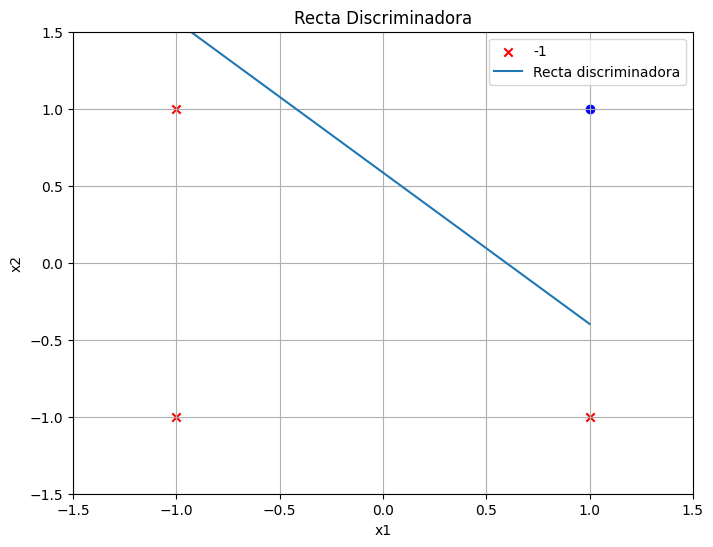

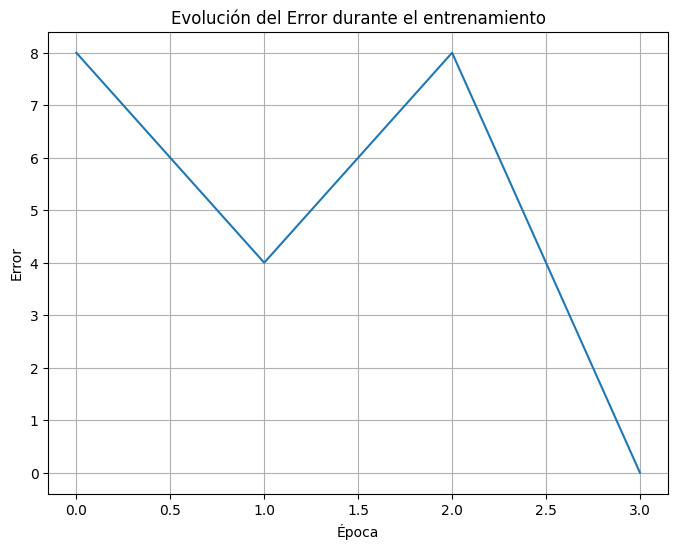

Pesos finales para OR: [0.63322309 0.47642007 0.23218207]


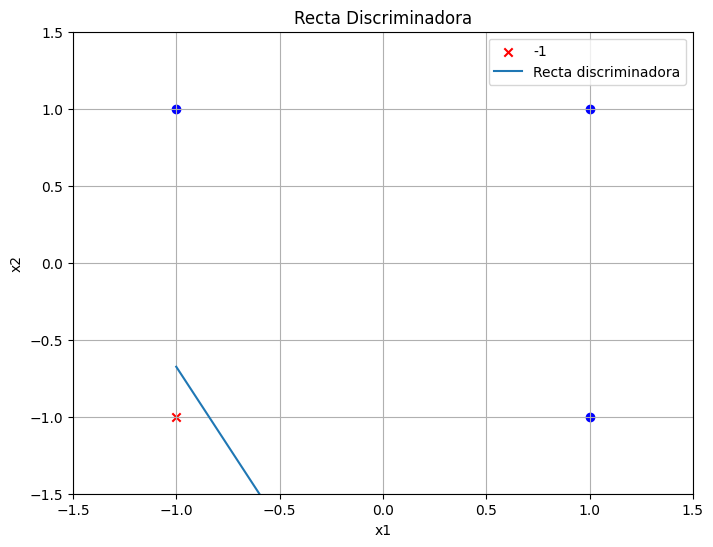

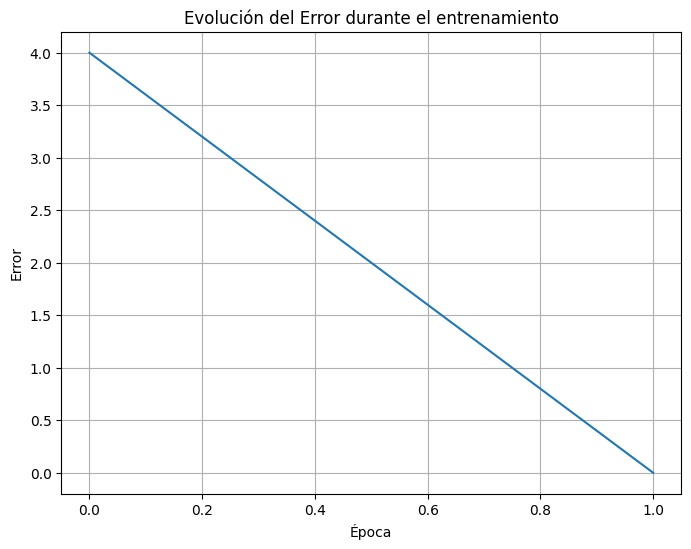

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Función de activación
def signo(h):
    return np.where(h >= 0, 1, -1)

# Función de entrenamiento
def entrenar_perceptron(X, y_d, eta, epocas):
    # Inicialización de pesos aleatoria
    W = np.random.rand(X.shape[1])
    errores = []
    
    for epoca in range(epocas):
        E = 0
        for i in range(len(X)):
            y = signo(np.dot(W, X[i]))
            error = y_d[i] - y
            W += eta * error * X[i]  # Regla de aprendizaje
            E += error**2
        errores.append(E)
        if E == 0:  # Si no hay errores, detener el entrenamiento
            break
    return W, errores

# Graficar los datos y la recta discriminadora
def graficar(X, W, y_d):
    plt.figure(figsize=(8,6))
    
    # Graficar los puntos
    for i in range(len(X)):
        if y_d[i] == 1:
            plt.scatter(X[i][1], X[i][2], marker='o', color='blue', label='1' if i == 0 else "")
        else:
            plt.scatter(X[i][1], X[i][2], marker='x', color='red', label='-1' if i == 0 else "")
    
    # Graficar la recta discriminadora
    x_vals = np.array([-1, 1])
    y_vals = -(W[1] / W[2]) * x_vals - (W[0] / W[2])
    plt.plot(x_vals, y_vals, label='Recta discriminadora')

    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True)
    plt.title('Recta Discriminadora')
    plt.show()

# Graficar la evolución del error
def graficar_error(errores):
    plt.figure(figsize=(8,6))
    plt.plot(errores)
    plt.xlabel('Época')
    plt.ylabel('Error')
    plt.title('Evolución del Error durante el entrenamiento')
    plt.grid(True)
    plt.show()

# Datos de entrenamiento AND
X_and = np.array([[1, -1, -1], [1, -1, 1], [1, 1, -1], [1, 1, 1]])  # Agregamos un "1" para w0
y_and = np.array([-1, -1, -1, 1])

# Datos de entrenamiento OR
X_or = np.array([[1, -1, -1], [1, -1, 1], [1, 1, -1], [1, 1, 1]])
y_or = np.array([-1, 1, 1, 1])

# Parámetros
eta = 0.1  # Tasa de aprendizaje
epocas = 100

# Entrenamiento para AND
W_and, errores_and = entrenar_perceptron(X_and, y_and, eta, epocas)
print("Pesos finales para AND:", W_and)
graficar(X_and, W_and, y_and)
graficar_error(errores_and)

# Entrenamiento para OR
W_or, errores_or = entrenar_perceptron(X_or, y_or, eta, epocas)
print("Pesos finales para OR:", W_or)
graficar(X_or, W_or, y_or)
graficar_error(errores_or)
